Все библиотеки загружены!
Данные загружены!
Размер данных: 500 строк, 11 столбцов

Первые 5 строк данных:


,id,property_type House,property_type Condo,property_type Town,property_type Apartment,garage,interior_space_sqm,land_size_sqm,property_age_years,sale_price_usd,LN
0,1,1,0,0,0,1,187,250,7,394367.73,12.885039
1,2,0,1,0,0,0,105,49,24,199577.41,12.203957
2,3,0,0,1,0,1,157,163,3,428924.38,12.969036
3,4,0,0,0,1,0,92,35,31,144153.38,11.878633
4,5,1,0,0,0,1,177,201,37,394943.83,12.886499


Распределение типов недвижимости:
property_type
House        223
Apartment    123
Town          99
Condo         55
Name: count, dtype: int64

Предобработка завершена!


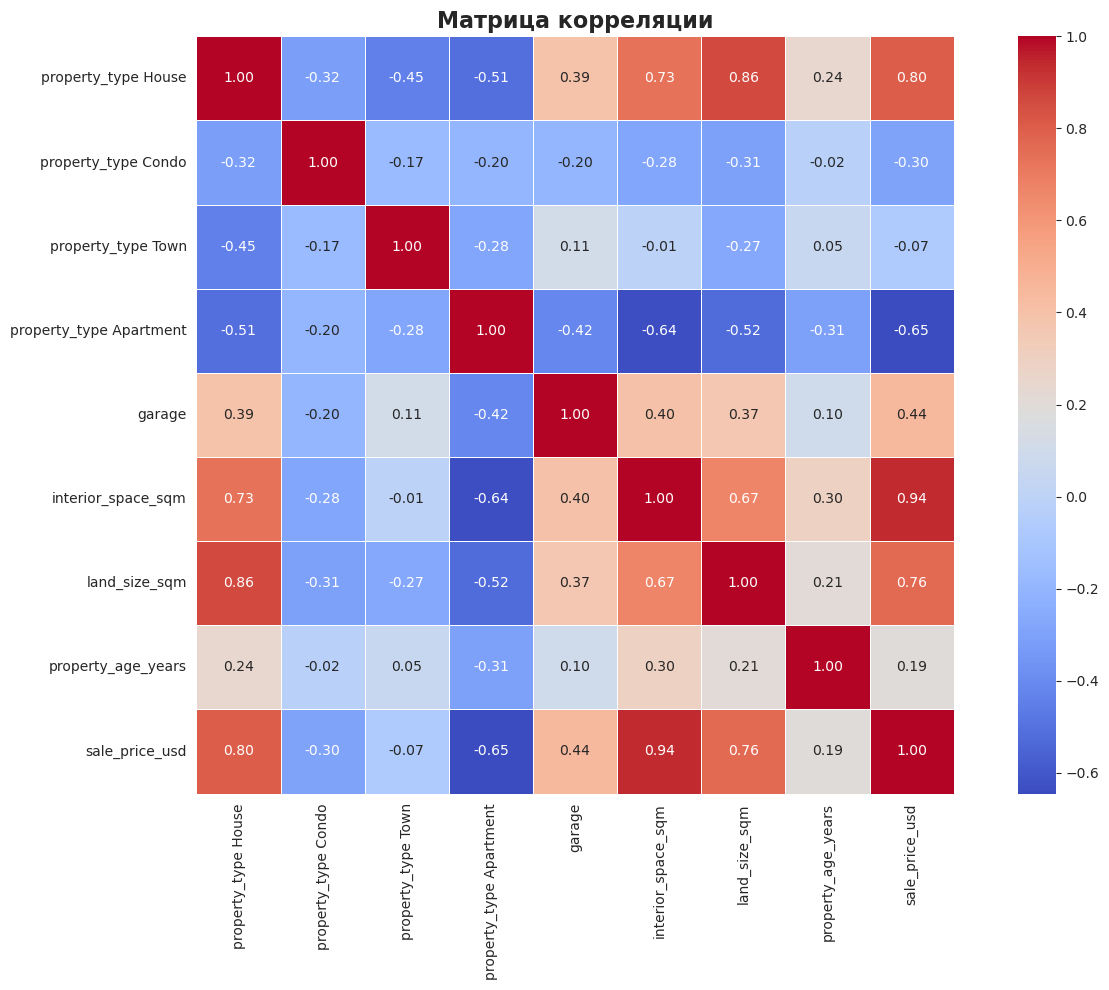

Корреляции с ценой:
sale_price_usd             1.000
interior_space_sqm         0.937
property_type House        0.801
land_size_sqm              0.765
garage                     0.443
property_age_years         0.191
property_type Town        -0.070
property_type Condo       -0.296
property_type Apartment   -0.645
Name: sale_price_usd, dtype: float64

Корреляционный анализ завершен!
РЕЗУЛЬТАТЫ РЕГРЕССИИ
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     574.4
Date:                Sat, 29 Aug 2026   Prob (F-statistic):          7.80e-219
Time:                        15:19:03   Log-Likelihood:                 162.85
No. Observations:                 500   AIC:                            -311.7
Df Residuals:                     493  

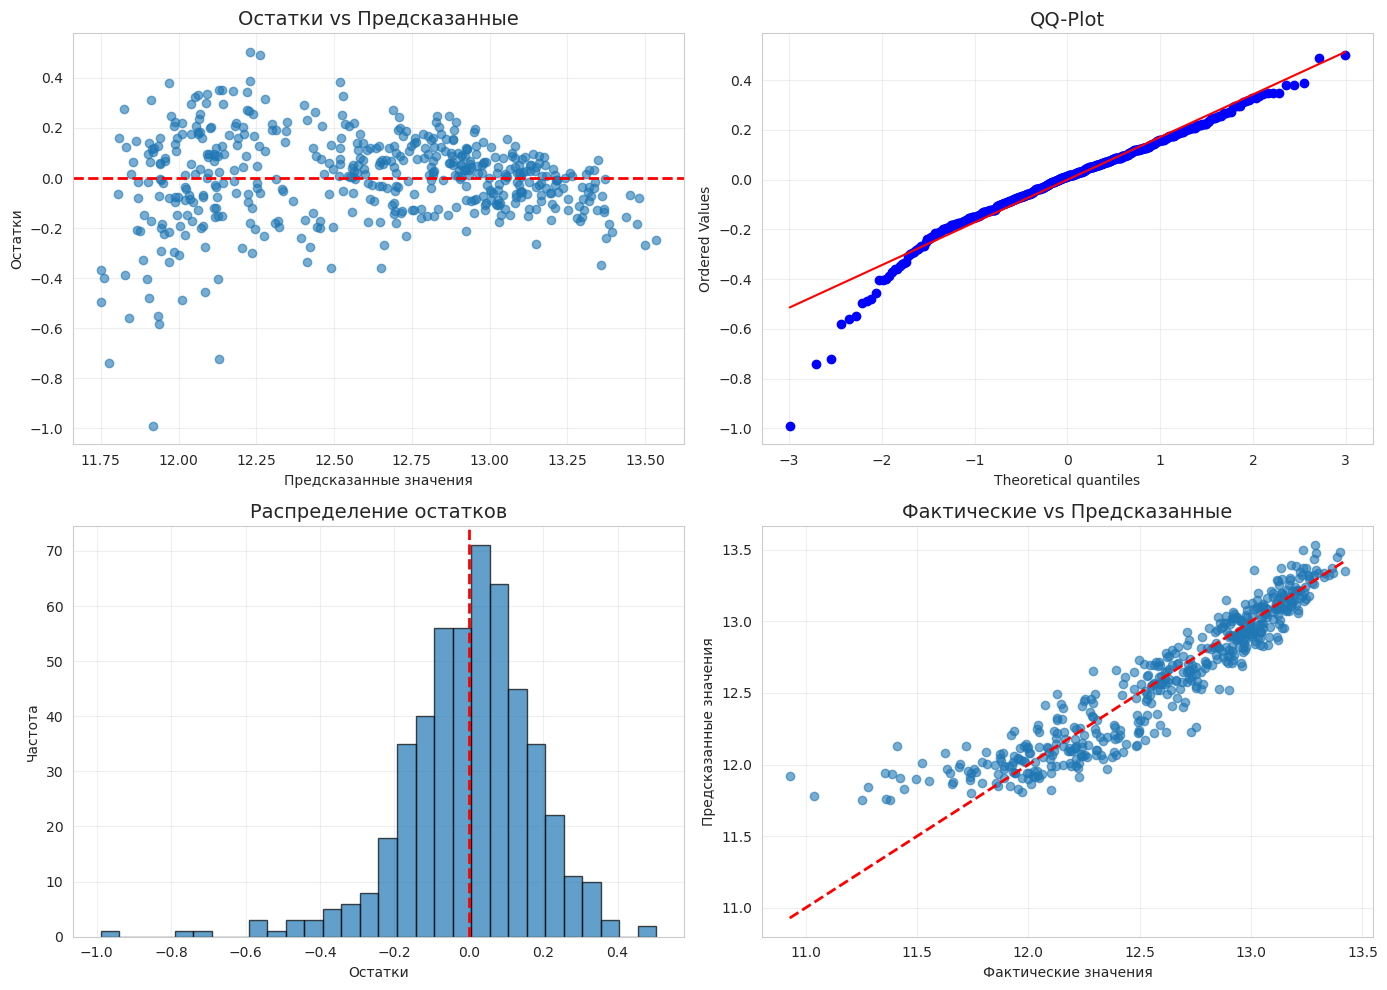

 Визуализация завершена!
ПРОГНОЗ ЦЕНЫ
Квартира (100 кв.м, без гаража, 5 лет): $191,891.93
Дом (200 кв.м, с гаражом, 10 лет): $547,676.19
 Сохранено: инальные_коэффициенты.xlsx
 Сохранено: анные_с_прогнозами.xlsx



In [1]:
import micropip
await micropip.install('pandas')
await micropip.install('numpy')
await micropip.install('matplotlib')
await micropip.install('seaborn')
await micropip.install('scikit-learn')
await micropip.install('statsmodels')
await micropip.install('openpyxl')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Все библиотеки загружены!")

file_path = 'Датасат - данный по ценам на недвижимость.xlsx'
df = pd.read_excel(file_path, sheet_name='Лист1')

print("Данные загружены!")
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 5 строк данных:")
display(df.head())

df['log_price'] = np.log(df['sale_price_usd'])
df = df.drop(columns=['LN'])

def get_property_type(row):
    if row['property_type House'] == 1:
        return 'House'
    elif row['property_type Condo'] == 1:
        return 'Condo'
    elif row['property_type Town'] == 1:
        return 'Town'
    elif row['property_type Apartment'] == 1:
        return 'Apartment'
    else:
        return 'Unknown'

df['property_type'] = df.apply(get_property_type, axis=1)

print("Распределение типов недвижимости:")
print(df['property_type'].value_counts())
print("\nПредобработка завершена!")

numeric_cols = ['property_type House', 'property_type Condo', 'property_type Town', 
                'property_type Apartment', 'garage', 'interior_space_sqm', 
                'land_size_sqm', 'property_age_years', 'sale_price_usd']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True)
plt.title('Матрица корреляции', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Корреляции с ценой:")
print(corr_matrix['sale_price_usd'].sort_values(ascending=False).round(3))
print("\nКорреляционный анализ завершен!")

features = ['property_type Condo', 'property_type Town', 'property_type Apartment',
            'garage', 'interior_space_sqm', 'property_age_years']

X = df[features]
X = sm.add_constant(X)
y = df['log_price']

model = sm.OLS(y, X)
results = model.fit()

print("="*70)
print("РЕЗУЛЬТАТЫ РЕГРЕССИИ")
print("="*70)
print(results.summary())

bp_test = het_breuschpagan(results.resid, X)

print("="*70)
print("ДИАГНОСТИКА МОДЕЛИ")
print("="*70)
print(f"\nТест Бройша-Пагана:")
print(f"  P-значение: {bp_test[1]:.4f}")

if bp_test[1] > 0.05:
    print("  Гомоскедастичность")
else:
    print("  Гетероскедастичность (исправим)")

# VIF анализ
vif_data = pd.DataFrame()
vif_data["Признак"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\nVIF анализ:")
print(vif_data)

high_vif = vif_data[(vif_data['VIF'] > 10) & (vif_data['Признак'] != 'const')]
if len(high_vif) > 0:
    print(f"\n⚠ Высокий VIF у: {high_vif['Признак'].tolist()}")
else:
    print("\n Мультиколлинеарности нет")

print("="*70)
print("ИСПРАВЛЕНИЕ ГЕТЕРОСКЕДАСТИЧНОСТИ")
print("="*70)

robust_results = results.get_robustcov_results(cov_type='HC3')

print("\nМОДЕЛЬ С РОБАСТНЫМИ ОШИБКАМИ:")
print(robust_results.summary())

print("\n" + "="*70)
print("СРАВНЕНИЕ СТАНДАРТНЫХ ОШИБОК")
print("="*70)

feature_names = results.params.index.tolist()

comparison = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': results.params.values,
    'Обычная ошибка': results.bse.values,
    'Робастная ошибка (HC3)': robust_results.bse,
    'Изменение (%)': ((robust_results.bse - results.bse) / results.bse * 100).round(2)
})

print(comparison)

print("\n Гетероскедастичность исправлена!")

print("="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*70)

feature_names = results.params.index.tolist()

coefs_values = robust_results.params
pvals_values = robust_results.pvalues

print(f"\nR-квадрат: {robust_results.rsquared:.4f}")
print(f"Скорректированный R-квадрат: {robust_results.rsquared_adj:.4f}")

print("\nЗНАЧИМЫЕ ФАКТОРЫ (p < 0.05):")
for i, name in enumerate(feature_names):
    if name == 'const':
        continue
    if pvals_values[i] < 0.05:
        coef = coefs_values[i]
        if name == 'interior_space_sqm':
            print(f"  {name}: +{coef*100:.2f}% за 1 кв.м (p={pvals_values[i]:.4e})")
        elif name == 'garage':
            print(f"  {name}: +{coef*100:.2f}% (p={pvals_values[i]:.4e})")
        elif name == 'property_age_years':
            print(f"  {name}: -{abs(coef)*100:.2f}% в год (p={pvals_values[i]:.4e})")
        else:
            print(f"  {name}: {coef:.4f} (p={pvals_values[i]:.4e})")

print("\nНЕЗНАЧИМЫЕ ФАКТОРЫ (p >= 0.05):")
for i, name in enumerate(feature_names):
    if name == 'const':
        continue
    if pvals_values[i] >= 0.05:
        print(f"  {name}: p={pvals_values[i]:.4f}")

print("\n" + "="*70)
print("ВЫВОДЫ:")
print("="*70)
print("1. Жилая площадь - главный фактор")
print("2. Гараж увеличивает стоимость")
print("3. Возраст снижает стоимость")
print("4. Тип недвижимости НЕ влияет на цену")
print("5. Модель объясняет 87.5% вариации цен")

predictions = robust_results.fittedvalues
residuals_robust = robust_results.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(predictions, residuals_robust, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_title('Остатки vs Предсказанные', fontsize=14)
axes[0, 0].set_xlabel('Предсказанные значения')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(residuals_robust, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ-Plot', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(residuals_robust, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_title('Распределение остатков', fontsize=14)
axes[1, 0].set_xlabel('Остатки')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y, predictions, alpha=0.6)
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[1, 1].set_title('Фактические vs Предсказанные', fontsize=14)
axes[1, 1].set_xlabel('Фактические значения')
axes[1, 1].set_ylabel('Предсказанные значения')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Визуализация завершена!")

new_apartment = pd.DataFrame({
    'const': [1],
    'property_type Condo': [0],
    'property_type Town': [0],
    'property_type Apartment': [1],
    'garage': [0],
    'interior_space_sqm': [100],
    'property_age_years': [5]
})

new_house = pd.DataFrame({
    'const': [1],
    'property_type Condo': [0],
    'property_type Town': [0],
    'property_type Apartment': [0],
    'garage': [1],
    'interior_space_sqm': [200],
    'property_age_years': [10]
})

pred_apt = np.exp(robust_results.predict(new_apartment)[0])
pred_house = np.exp(robust_results.predict(new_house)[0])

print("="*70)
print("ПРОГНОЗ ЦЕНЫ")
print("="*70)
print(f"Квартира (100 кв.м, без гаража, 5 лет): ${pred_apt:,.2f}")
print(f"Дом (200 кв.м, с гаражом, 10 лет): ${pred_house:,.2f}")

final_coefs = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefs_values,
    'Ошибка': robust_results.bse,
    'P-значение': pvals_values
})
final_coefs.to_excel('Финальные_коэффициенты.xlsx', index=False)
print(" Сохранено: инальные_коэффициенты.xlsx")

df_with_pred = df.copy()
df_with_pred['predicted_log_price'] = robust_results.fittedvalues
df_with_pred['predicted_price'] = np.exp(robust_results.fittedvalues)
df_with_pred['residual'] = robust_results.resid
df_with_pred.to_excel('Данные_с_прогнозами.xlsx', index=False)
print(" Сохранено: анные_с_прогнозами.xlsx")

print("\n" + "="*70)
print("="*70)